# 02 — MCQ Answers (20 điểm)

**Mục tiêu:** Tính toán chính xác đáp án cho 10 câu trắc nghiệm.  
Mỗi câu 2 điểm, không trừ điểm sai → mục tiêu **20/20**.

---

In [14]:
# ── Setup ──────────────────────────────────────────────────────────────
import sys, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
from data_loader import (
    load_orders, load_order_items, load_products, load_customers,
    load_geography, load_payments, load_returns, load_web_traffic,
)

# ── Style ──
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'axes.edgecolor': '#333',
    'axes.labelcolor': '#ccc',
    'text.color': '#ccc',
    'xtick.color': '#999',
    'ytick.color': '#999',
    'grid.color': '#222',
    'font.size': 11,
    'axes.titlesize': 14,
    'figure.dpi': 110,
})

# Color palette
COLORS = ['#4fc3f7', '#81c784', '#ffb74d', '#e57373', '#ba68c8', '#4db6ac']
HIGHLIGHT = '#4fc3f7'
DIMMED = '#555555'

# Dict to collect final answers
ANSWERS = {}
print('✅ Setup complete')

✅ Setup complete


---
## Q1 — Trung vị inter-order gap (2đ)

**Đề:** Khách hàng có >1 đơn, trung vị số ngày giữa 2 lần mua liên tiếp?  
**Đáp án:** A) 30 / B) 90 / C) 180 / D) 365

In [15]:
orders = load_orders()

# Lọc khách có > 1 đơn
multi = orders.groupby('customer_id').filter(lambda x: len(x) > 1)
print(f"Khách có >1 đơn: {multi['customer_id'].nunique():,} khách, {len(multi):,} đơn")

# Sắp xếp theo customer + date
multi = multi.sort_values(['customer_id', 'order_date'])

# Tính gap giữa các đơn liên tiếp
multi['prev_date'] = multi.groupby('customer_id')['order_date'].shift(1)
multi['gap_days'] = (multi['order_date'] - multi['prev_date']).dt.days

# Trung vị
gaps = multi['gap_days'].dropna()
median_gap = gaps.median()
print(f"\nSố cặp đơn liên tiếp: {len(gaps):,}")
print(f"Median inter-order gap: {median_gap:.0f} ngày")
print(f"Mean: {gaps.mean():.0f} | Q25: {gaps.quantile(0.25):.0f} | Q75: {gaps.quantile(0.75):.0f}")

# Map to answer choices
choices = {'A': 30, 'B': 90, 'C': 180, 'D': 365}
best = min(choices, key=lambda k: abs(choices[k] - median_gap))
ANSWERS['Q1'] = best
print(f"\n→ Đáp án: {best}) {choices[best]} (median = {median_gap:.0f}, closest)")

Khách có >1 đơn: 67,888 khách, 624,587 đơn

Số cặp đơn liên tiếp: 556,699
Median inter-order gap: 144 ngày
Mean: 286 | Q25: 46 | Q75: 357

→ Đáp án: C) 180 (median = 144, closest)


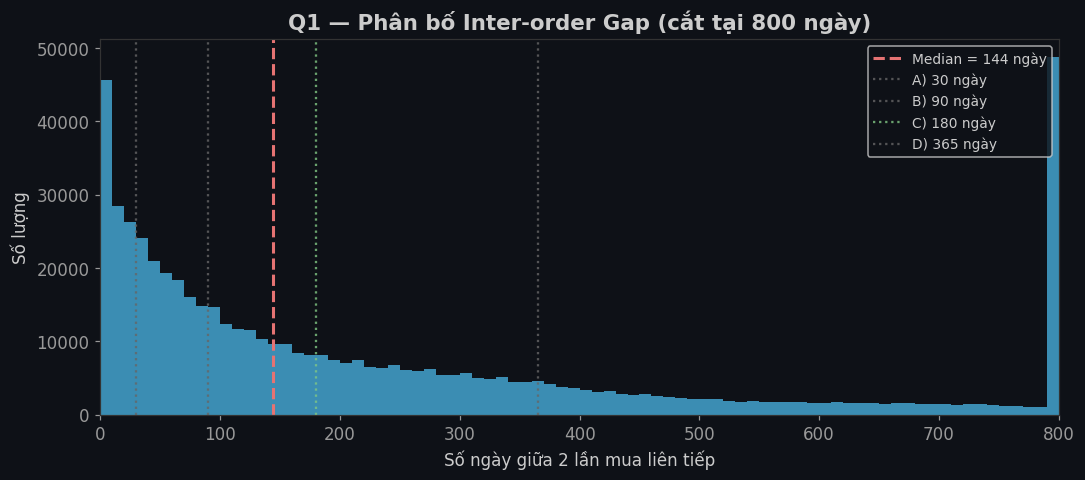

In [16]:
# ── Q1 Chart: Histogram of inter-order gaps ──
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.hist(gaps.clip(upper=800), bins=80, color=HIGHLIGHT, alpha=0.7, edgecolor='none')

# Median line
ax.axvline(median_gap, color='#e57373', linewidth=2, linestyle='--',
           label=f'Median = {median_gap:.0f} ngày')

# Answer choice markers
for label, val in choices.items():
    c = '#81c784' if label == best else '#666'
    ax.axvline(val, color=c, linewidth=1.5, linestyle=':',
               label=f'{label}) {val} ngày', alpha=0.8)

ax.set_xlabel('Số ngày giữa 2 lần mua liên tiếp')
ax.set_ylabel('Số lượng')
ax.set_title('Q1 — Phân bố Inter-order Gap (cắt tại 800 ngày)', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 800)
plt.tight_layout()
plt.show()

---
## Q2 — Segment có gross margin TB cao nhất (2đ)

**Đề:** Segment nào có `(price - cogs) / price` trung bình cao nhất?  
**Đáp án:** A) Premium / B) Performance / C) Activewear / D) Standard

In [17]:
products = load_products()

products['gross_margin'] = (products['price'] - products['cogs']) / products['price']
margin_by_seg = products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False)
print("Gross margin trung bình theo segment:")
print(margin_by_seg.to_string())

top_seg = margin_by_seg.index[0]
answer_map = {'Premium': 'A', 'Performance': 'B', 'Activewear': 'C', 'Standard': 'D'}
ANSWERS['Q2'] = answer_map.get(top_seg, '?')
print(f"\n→ Đáp án: {ANSWERS['Q2']}) {top_seg} (margin = {margin_by_seg.iloc[0]:.4f})")

Gross margin trung bình theo segment:
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343

→ Đáp án: D) Standard (margin = 0.3134)


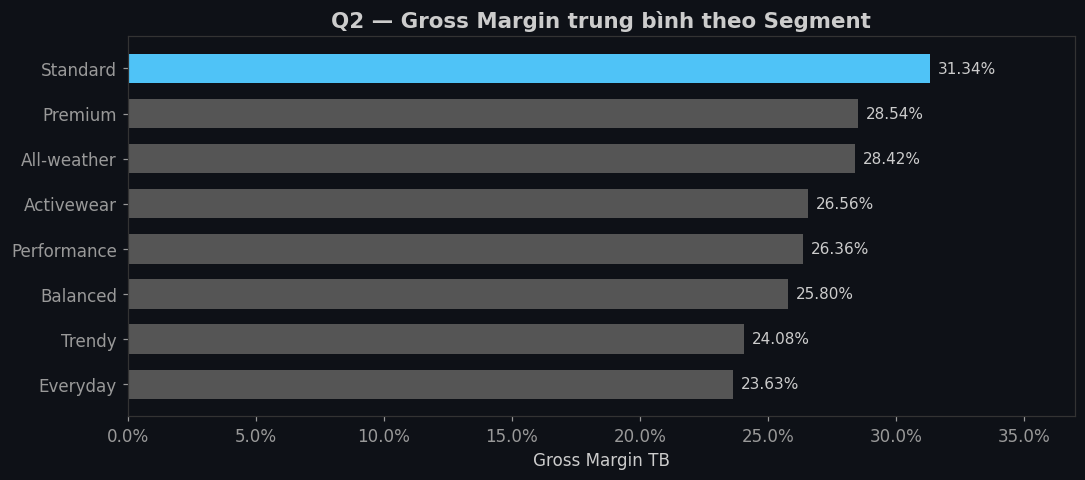

In [18]:
# ── Q2 Chart: Horizontal bar — Gross margin by segment ──
fig, ax = plt.subplots(figsize=(10, 4.5))

segments = margin_by_seg.index[::-1]
values = margin_by_seg.values[::-1]
bar_colors = [HIGHLIGHT if s == top_seg else DIMMED for s in segments]

bars = ax.barh(segments, values, color=bar_colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.2%}', va='center', fontsize=10, color='#ccc')

ax.set_xlabel('Gross Margin TB')
ax.set_title('Q2 — Gross Margin trung bình theo Segment', fontweight='bold')
ax.set_xlim(0, max(values) * 1.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

---
## Q3 — Lý do trả hàng phổ biến nhất cho Streetwear (2đ)

**Đề:** Category Streetwear, return_reason nào xuất hiện nhiều nhất?  
**Đáp án:** A) defective / B) wrong_size / C) changed_mind / D) not_as_described

In [19]:
returns = load_returns()

# Join returns với products để lấy category
ret_prod = returns.merge(products[['product_id', 'category']], on='product_id')
streetwear = ret_prod[ret_prod['category'] == 'Streetwear']
print(f"Số returns cho Streetwear: {len(streetwear):,}")

reason_counts = streetwear['return_reason'].value_counts()
print("\nReturn reasons:")
print(reason_counts.to_string())

top_reason = reason_counts.index[0]
answer_map = {'defective': 'A', 'wrong_size': 'B', 'changed_mind': 'C', 'not_as_described': 'D'}
ANSWERS['Q3'] = answer_map.get(top_reason, '?')
print(f"\n→ Đáp án: {ANSWERS['Q3']}) {top_reason} ({reason_counts.iloc[0]:,} lần)")

Số returns cho Streetwear: 21,799

Return reasons:
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159

→ Đáp án: B) wrong_size (7,626 lần)


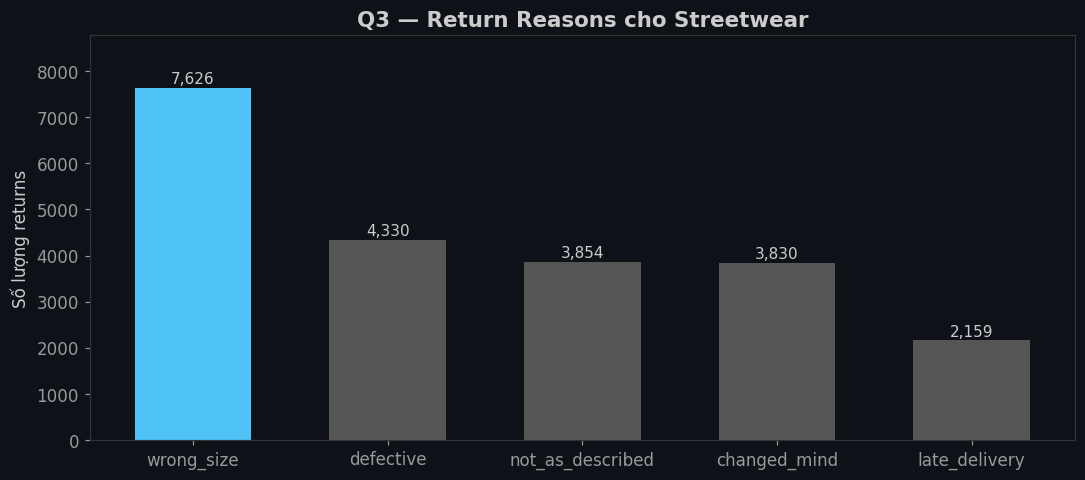

In [20]:
# ── Q3 Chart: Bar — Return reasons for Streetwear ──
fig, ax = plt.subplots(figsize=(10, 4.5))

reasons = reason_counts.index
vals = reason_counts.values
bar_colors = [HIGHLIGHT if r == top_reason else DIMMED for r in reasons]

bars = ax.bar(reasons, vals, color=bar_colors, edgecolor='none', width=0.6)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=10, color='#ccc')

ax.set_ylabel('Số lượng returns')
ax.set_title('Q3 — Return Reasons cho Streetwear', fontweight='bold')
ax.set_ylim(0, max(vals) * 1.15)
plt.tight_layout()
plt.show()

---
## Q4 — Traffic source có bounce_rate TB thấp nhất (2đ)

**Đề:** Trong web_traffic.csv, source nào bounce_rate TB thấp nhất?  
**Đáp án:** A) organic_search / B) paid_search / C) email_campaign / D) social_media

In [21]:
traffic = load_web_traffic()

bounce_by_source = traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()
print("Bounce rate trung bình theo source:")
print(bounce_by_source.to_string())

lowest_source = bounce_by_source.index[0]
answer_map = {'organic_search': 'A', 'paid_search': 'B', 'email_campaign': 'C', 'social_media': 'D'}
ANSWERS['Q4'] = answer_map.get(lowest_source, '?')
print(f"\n→ Đáp án: {ANSWERS['Q4']}) {lowest_source} (bounce = {bounce_by_source.iloc[0]:.6f})")
print(f"⚠️ Lưu ý: các giá trị rất gần nhau (range = {bounce_by_source.max() - bounce_by_source.min():.6f})")

Bounce rate trung bình theo source:
traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511

→ Đáp án: C) email_campaign (bounce = 0.004458)
⚠️ Lưu ý: các giá trị rất gần nhau (range = 0.000052)


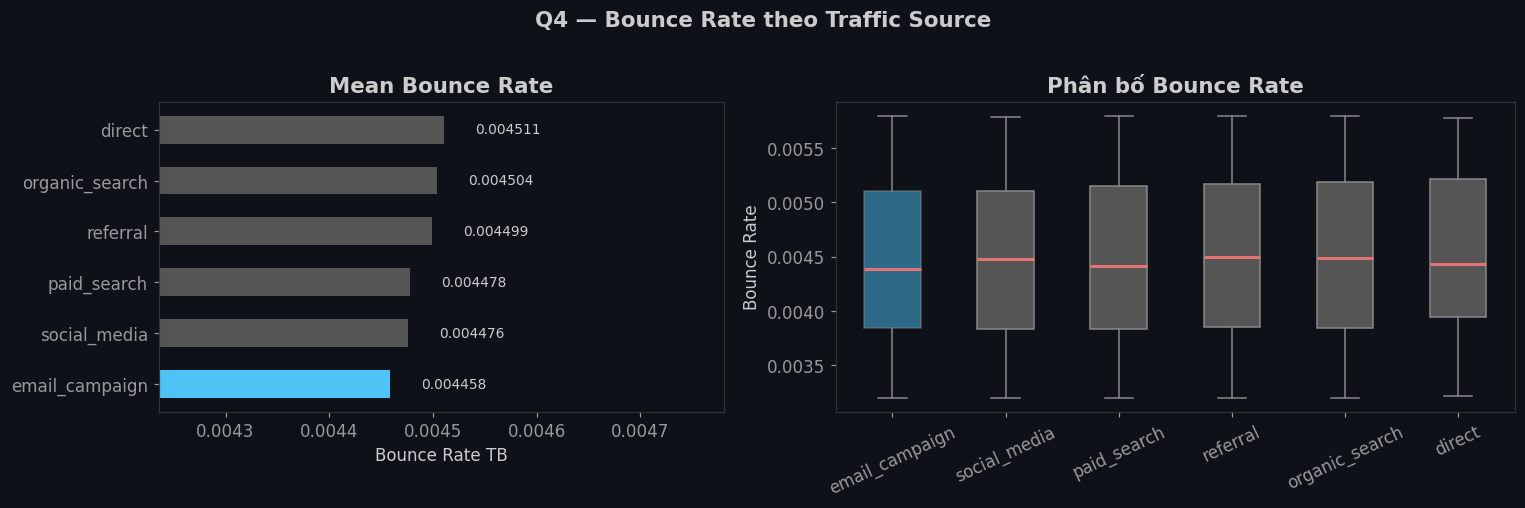

In [22]:
# ── Q4 Chart: Horizontal bar — Bounce rate by source + Boxplot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Left: Mean bar chart
sources = bounce_by_source.index
vals = bounce_by_source.values
bar_colors = [HIGHLIGHT if s == lowest_source else DIMMED for s in sources]

bars = ax1.barh(sources, vals, color=bar_colors, edgecolor='none', height=0.55)
for bar, val in zip(bars, vals):
    ax1.text(val + 0.00003, bar.get_y() + bar.get_height()/2,
             f'{val:.6f}', va='center', fontsize=9, color='#ccc')

ax1.set_xlabel('Bounce Rate TB')
ax1.set_title('Mean Bounce Rate', fontweight='bold')
ax1.set_xlim(min(vals) * 0.95, max(vals) * 1.06)

# Right: Boxplot for distribution
source_list = bounce_by_source.index.tolist()
data_groups = [traffic[traffic['traffic_source'] == s]['bounce_rate'].values for s in source_list]

bp = ax2.boxplot(data_groups, labels=source_list, vert=True, patch_artist=True,
                 boxprops=dict(facecolor=DIMMED, edgecolor='#888'),
                 medianprops=dict(color='#e57373', linewidth=2),
                 whiskerprops=dict(color='#888'),
                 capprops=dict(color='#888'),
                 flierprops=dict(marker='.', markerfacecolor='#666', markersize=3))

# Highlight the answer box
answer_idx = source_list.index(lowest_source)
bp['boxes'][answer_idx].set_facecolor(HIGHLIGHT)
bp['boxes'][answer_idx].set_alpha(0.5)

ax2.tick_params(axis='x', rotation=25)
ax2.set_ylabel('Bounce Rate')
ax2.set_title('Phân bố Bounce Rate', fontweight='bold')

fig.suptitle('Q4 — Bounce Rate theo Traffic Source', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Q5 — % order_items có promo (2đ)

**Đề:** Tỷ lệ dòng order_items có promo_id != null?  
**Đáp án:** A) 12% / B) 25% / C) 39% / D) 54%

In [23]:
items = load_order_items()

total_items = len(items)
with_promo = items['promo_id'].notna().sum()
pct_promo = with_promo / total_items * 100

print(f"Tổng order_items: {total_items:,}")
print(f"Có promo_id:      {with_promo:,}")
print(f"% with promo:     {pct_promo:.1f}%")

# Cũng kiểm tra promo_id_2
with_promo2 = items['promo_id_2'].notna().sum()
print(f"\nCó promo_id_2:    {with_promo2:,} ({with_promo2/total_items*100:.1f}%)")

choices = {'A': 12, 'B': 25, 'C': 39, 'D': 54}
best = min(choices, key=lambda k: abs(choices[k] - pct_promo))
ANSWERS['Q5'] = best
print(f"\n→ Đáp án: {best}) {choices[best]}% (thực tế = {pct_promo:.1f}%)")

Tổng order_items: 714,669
Có promo_id:      276,316
% with promo:     38.7%

Có promo_id_2:    206 (0.0%)

→ Đáp án: C) 39% (thực tế = 38.7%)


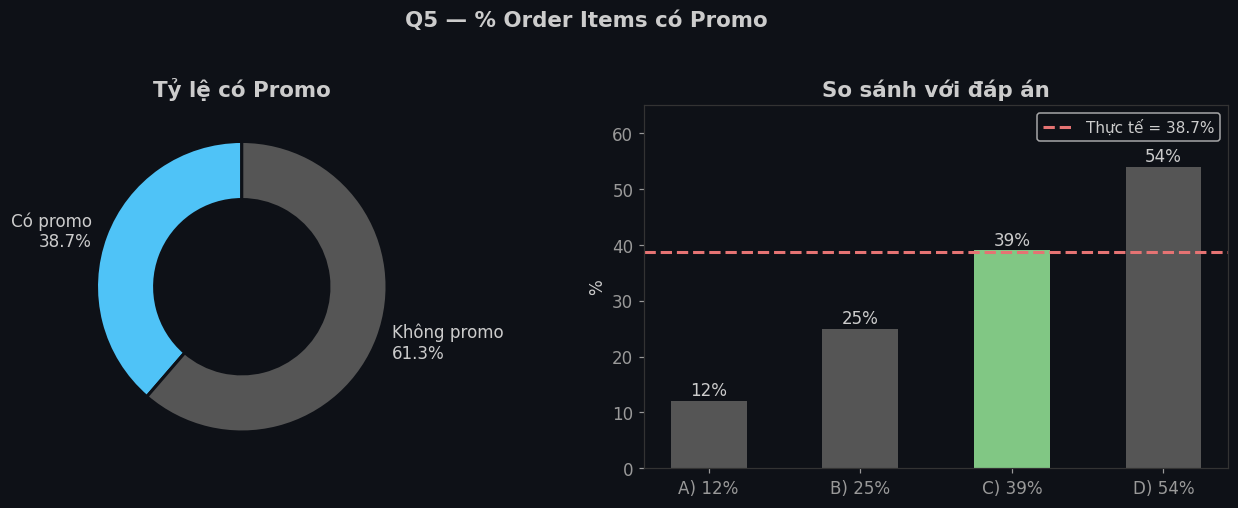

In [24]:
# ── Q5 Chart: Donut + answer markers ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Donut chart
sizes = [pct_promo, 100 - pct_promo]
labels_donut = [f'Có promo\n{pct_promo:.1f}%', f'Không promo\n{100-pct_promo:.1f}%']
colors_donut = [HIGHLIGHT, DIMMED]

wedges, texts = ax1.pie(sizes, labels=labels_donut, colors=colors_donut,
                        startangle=90, textprops={'color': '#ccc', 'fontsize': 11},
                        wedgeprops={'width': 0.4, 'edgecolor': '#0e1117', 'linewidth': 2})
ax1.set_title('Tỷ lệ có Promo', fontweight='bold')

# Right: Answer choices comparison
choice_labels = [f'{k}) {v}%' for k, v in choices.items()]
choice_vals = list(choices.values())
bar_colors = ['#81c784' if k == best else DIMMED for k in choices]

bars = ax2.bar(choice_labels, choice_vals, color=bar_colors, edgecolor='none', width=0.5)
ax2.axhline(pct_promo, color='#e57373', linewidth=2, linestyle='--',
            label=f'Thực tế = {pct_promo:.1f}%')

for bar, val in zip(bars, choice_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontsize=11, color='#ccc')

ax2.set_ylabel('%')
ax2.set_title('So sánh với đáp án', fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 65)

fig.suptitle('Q5 — % Order Items có Promo', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Q6 — Age_group có số đơn TB/khách cao nhất (2đ)

**Đề:** Nhóm tuổi (age_group != null) nào có `tổng đơn / số khách` cao nhất?  
**Đáp án:** A) 55+ / B) 25–34 / C) 35–44 / D) 45–54

> **Lưu ý:** Mẫu số = số khách **trong nhóm tuổi** (từ customers.csv), không phải số khách có đơn.

In [25]:
customers = load_customers()

# Lọc age_group != null
valid_cust = customers[customers['age_group'].notna()]
print(f"Customers with age_group: {len(valid_cust):,}")

# Join orders với valid customers
merged = orders.merge(valid_cust[['customer_id', 'age_group']], on='customer_id')

# Tổng đơn per group
orders_per_group = merged.groupby('age_group')['order_id'].count()

# Số khách duy nhất per group (mẫu số từ customers, KHÔNG phải từ orders)
customers_per_group = valid_cust.groupby('age_group')['customer_id'].nunique()

# Avg orders per customer
avg_orders = (orders_per_group / customers_per_group).sort_values(ascending=False)

print("\nSố đơn TB / khách theo nhóm tuổi:")
for ag, val in avg_orders.items():
    print(f"  {ag:>8s}: {val:.3f}  ({orders_per_group[ag]:,} đơn / {customers_per_group[ag]:,} khách)")

top_ag = avg_orders.index[0]
answer_map = {'55+': 'A', '25-34': 'B', '35-44': 'C', '45-54': 'D'}
ANSWERS['Q6'] = answer_map.get(top_ag, '?')
print(f"\n→ Đáp án: {ANSWERS['Q6']}) {top_ag} ({avg_orders.iloc[0]:.3f} đơn/khách)")

Customers with age_group: 121,930

Số đơn TB / khách theo nhóm tuổi:
       55+: 5.407  (72,760 đơn / 13,457 khách)
     45-54: 5.357  (124,138 đơn / 23,172 khách)
     35-44: 5.337  (170,368 đơn / 31,920 khách)
     25-34: 5.245  (190,622 đơn / 36,342 khách)
     18-24: 5.227  (89,057 đơn / 17,039 khách)

→ Đáp án: A) 55+ (5.407 đơn/khách)


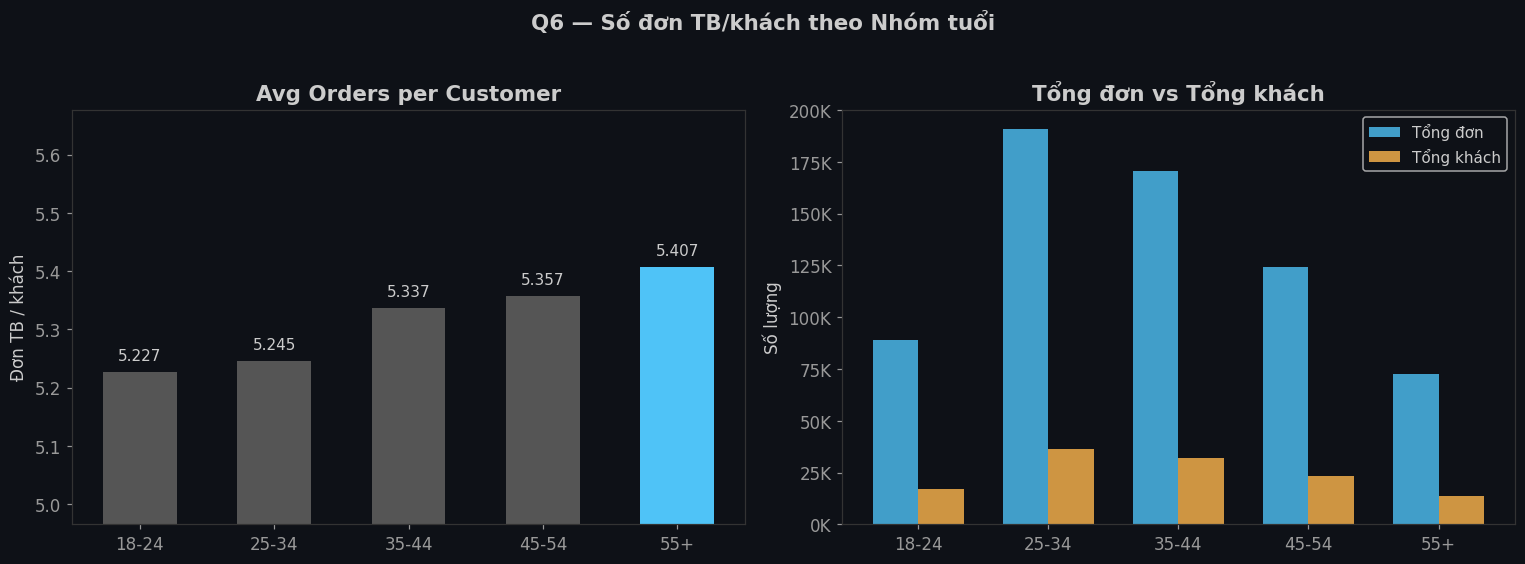

In [26]:
# ── Q6 Chart: Grouped bar — Orders/Customers/Avg per age group ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
avg_sorted = avg_orders.reindex(age_order)

# Left: Avg orders per customer
bar_colors = [HIGHLIGHT if ag == top_ag else DIMMED for ag in age_order]
bars = ax1.bar(age_order, avg_sorted.values, color=bar_colors, edgecolor='none', width=0.55)

for bar, val in zip(bars, avg_sorted.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=10, color='#ccc')

ax1.set_ylabel('Đơn TB / khách')
ax1.set_title('Avg Orders per Customer', fontweight='bold')
ax1.set_ylim(min(avg_sorted) * 0.95, max(avg_sorted) * 1.05)

# Right: Stacked — tổng đơn vs tổng khách
x = np.arange(len(age_order))
w = 0.35
o_vals = orders_per_group.reindex(age_order).values
c_vals = customers_per_group.reindex(age_order).values

ax2.bar(x - w/2, o_vals, w, label='Tổng đơn', color=HIGHLIGHT, alpha=0.8)
ax2.bar(x + w/2, c_vals, w, label='Tổng khách', color='#ffb74d', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(age_order)
ax2.set_ylabel('Số lượng')
ax2.set_title('Tổng đơn vs Tổng khách', fontweight='bold')
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.suptitle('Q6 — Số đơn TB/khách theo Nhóm tuổi', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Q7 — Region có tổng doanh thu cao nhất (2đ)

**Đề:** Region nào tạo ra tổng doanh thu cao nhất?  
**Đáp án:** A) West / B) Central / C) East / D) Cả ba xấp xỉ bằng nhau

> **Lưu ý:** Tính revenue từ `order_items` (quantity × unit_price) vì `sales.csv` không chứa region.  
> Cross-check bằng `payments.payment_value` để đảm bảo nhất quán.

In [ ]:
geo = load_geography()

# ── Cách 1: Revenue từ order_items ──
order_rev = items.groupby('order_id').apply(
    lambda x: (x['quantity'] * x['unit_price']).sum()
).reset_index(name='revenue')

orders_geo = orders.merge(geo[['zip', 'region']], on='zip')
orders_geo = orders_geo.merge(order_rev, on='order_id')

rev_method1 = orders_geo.groupby('region')['revenue'].sum().sort_values(ascending=False)
print("Cách 1 — Revenue từ order_items (quantity × unit_price):")
for r, v in rev_method1.items():
    print(f"  {r:>8s}: {v:>16,.0f}")

# ── Cách 2: Revenue từ payments ──
payments = load_payments()
orders_geo2 = orders.merge(geo[['zip', 'region']], on='zip')
orders_geo2 = orders_geo2.merge(payments[['order_id', 'payment_value']], on='order_id')

rev_method2 = orders_geo2.groupby('region')['payment_value'].sum().sort_values(ascending=False)
print("\nCách 2 — Revenue từ payments:")
for r, v in rev_method2.items():
    print(f"  {r:>8s}: {v:>16,.0f}")

# Cả hai cách đều cho cùng ranking
top_region = rev_method1.index[0]
ratio = rev_method1.max() / rev_method1.min()
print(f"\nRatio max/min: {ratio:.2f}x → KHÔNG xấp xỉ bằng nhau")

answer_map = {'West': 'A', 'Central': 'B', 'East': 'C'}
if ratio < 1.1:
    ANSWERS['Q7'] = 'D'  # xấp xỉ bằng nhau
    print("→ Đáp án: D) Cả ba xấp xỉ bằng nhau")
else:
    ANSWERS['Q7'] = answer_map.get(top_region, '?')
    print(f"\n→ Đáp án: {ANSWERS['Q7']}) {top_region}")

In [ ]:
# ── Q7 Chart: Side-by-side comparison of both methods ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

regions = rev_method1.index.tolist()

# Left: Bar chart comparing both methods
x = np.arange(len(regions))
w = 0.35
v1 = rev_method1.values
v2 = rev_method2.reindex(regions).values

ax1.bar(x - w/2, v1 / 1e9, w, label='order_items', color=HIGHLIGHT, alpha=0.85)
ax1.bar(x + w/2, v2 / 1e9, w, label='payments', color='#81c784', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(regions)
ax1.set_ylabel('Revenue (tỷ VND)')
ax1.set_title('So sánh 2 cách tính', fontweight='bold')
ax1.legend(fontsize=10)

for i, (a, b) in enumerate(zip(v1, v2)):
    ax1.text(i - w/2, a/1e9 + 0.1, f'{a/1e9:.1f}B', ha='center', fontsize=9, color='#ccc')
    ax1.text(i + w/2, b/1e9 + 0.1, f'{b/1e9:.1f}B', ha='center', fontsize=9, color='#ccc')

# Right: Pie chart — share of total
colors_pie = [HIGHLIGHT if r == top_region else '#555' if r == regions[-1] else '#777' for r in regions]
explode = [0.05 if r == top_region else 0 for r in regions]

wedges, texts, autotexts = ax2.pie(
    v1, labels=regions, autopct='%1.1f%%', colors=colors_pie,
    explode=explode, startangle=90,
    textprops={'color': '#ccc', 'fontsize': 12},
    pctdistance=0.6,
    wedgeprops={'edgecolor': '#0e1117', 'linewidth': 2}
)
for t in autotexts:
    t.set_color('#fff')
    t.set_fontweight('bold')
ax2.set_title('Tỷ trọng Revenue theo Region', fontweight='bold')

fig.suptitle('Q7 — Revenue theo Region', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Q8 — Payment method phổ biến nhất cho đơn cancelled (2đ)

**Đề:** Đơn cancelled dùng payment_method nào nhiều nhất?  
**Đáp án:** A) credit_card / B) cod / C) paypal / D) bank_transfer

In [ ]:
cancelled = orders[orders['order_status'] == 'cancelled']
print(f"Tổng đơn cancelled: {len(cancelled):,}")

pm_counts = cancelled['payment_method'].value_counts()
print("\nPayment method cho đơn cancelled:")
print(pm_counts.to_string())

top_pm = pm_counts.index[0]
answer_map = {'credit_card': 'A', 'cod': 'B', 'paypal': 'C', 'bank_transfer': 'D'}
ANSWERS['Q8'] = answer_map.get(top_pm, '?')
print(f"\n→ Đáp án: {ANSWERS['Q8']}) {top_pm} ({pm_counts.iloc[0]:,} đơn)")

In [ ]:
# ── Q8 Chart: Bar — cancelled orders by payment method + all orders comparison ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cancelled payment methods
pms = pm_counts.index
vals = pm_counts.values
bar_colors = [HIGHLIGHT if p == top_pm else DIMMED for p in pms]

bars = ax1.bar(pms, vals, color=bar_colors, edgecolor='none', width=0.55)
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', fontsize=9, color='#ccc')

ax1.set_ylabel('Số đơn cancelled')
ax1.set_title('Payment Method — Đơn Cancelled', fontweight='bold')
ax1.tick_params(axis='x', rotation=20)

# Right: Compare cancel rate per payment method
all_pm = orders['payment_method'].value_counts()
cancel_rate = (pm_counts / all_pm).dropna().sort_values(ascending=False)

cr_colors = [HIGHLIGHT if p == top_pm else '#777' for p in cancel_rate.index]
bars2 = ax2.barh(cancel_rate.index[::-1], cancel_rate.values[::-1],
                 color=cr_colors[::-1], edgecolor='none', height=0.55)

for bar, val in zip(bars2, cancel_rate.values[::-1]):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', fontsize=9, color='#ccc')

ax2.set_xlabel('Cancel Rate')
ax2.set_title('Cancel Rate theo Payment Method', fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.suptitle('Q8 — Payment Method cho Đơn Cancelled', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Q9 — Size có tỷ lệ trả hàng cao nhất (2đ)

**Đề:** Size (S/M/L/XL) nào có return rate cao nhất = `count(returns) / count(order_items)` theo product?  
**Đáp án:** A) S / B) M / C) L / D) XL

In [ ]:
# Số returns theo size
ret_with_size = returns.merge(products[['product_id', 'size']], on='product_id')
ret_count = ret_with_size.groupby('size').size()

# Số order_items theo size
items_with_size = items.merge(products[['product_id', 'size']], on='product_id')
items_count = items_with_size.groupby('size').size()

# Return rate
return_rate = (ret_count / items_count).sort_values(ascending=False)

print("Return rate theo size:")
for sz, rate in return_rate.items():
    print(f"  {sz:>3s}: {rate:.4f}  ({ret_count[sz]:,} returns / {items_count[sz]:,} items)")

top_size = return_rate.index[0]
answer_map = {'S': 'A', 'M': 'B', 'L': 'C', 'XL': 'D'}
ANSWERS['Q9'] = answer_map.get(top_size, '?')
print(f"\n→ Đáp án: {ANSWERS['Q9']}) {top_size} (rate = {return_rate.iloc[0]:.4f})")

In [ ]:
# ── Q9 Chart: Return rate + raw counts by size ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

size_order = ['S', 'M', 'L', 'XL']
rr_sorted = return_rate.reindex(size_order)

# Left: Return rate
bar_colors = [HIGHLIGHT if s == top_size else DIMMED for s in size_order]
bars = ax1.bar(size_order, rr_sorted.values, color=bar_colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, rr_sorted.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', fontsize=11, color='#ccc')

ax1.set_ylabel('Return Rate')
ax1.set_title('Return Rate = returns / order_items', fontweight='bold')
ax1.set_ylim(min(rr_sorted) * 0.95, max(rr_sorted) * 1.04)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

# Right: Stacked counts
x = np.arange(len(size_order))
w = 0.35
ret_vals = ret_count.reindex(size_order).values
item_vals = items_count.reindex(size_order).values

ax2.bar(x - w/2, item_vals, w, label='Order Items', color='#777', alpha=0.8)
ax2.bar(x + w/2, ret_vals, w, label='Returns', color='#e57373', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(size_order)
ax2.set_ylabel('Số lượng')
ax2.set_title('Tổng Items vs Returns', fontweight='bold')
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.suptitle('Q9 — Return Rate theo Size', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Q10 — Installment plan có payment value TB cao nhất (2đ)

**Đề:** Kế hoạch trả góp nào có payment_value trung bình cao nhất?  
**Đáp án:** A) 1 kỳ / B) 3 kỳ / C) 6 kỳ / D) 12 kỳ

In [ ]:
avg_payment = payments.groupby('installments')['payment_value'].agg(['mean', 'count'])
avg_payment = avg_payment.sort_values('mean', ascending=False)

print("Avg payment_value theo installments:")
for inst, row in avg_payment.iterrows():
    print(f"  {inst:>2d} kỳ: {row['mean']:>12,.2f}  (n = {row['count']:,.0f})")

top_inst = avg_payment.index[0]
answer_map = {1: 'A', 3: 'B', 6: 'C', 12: 'D'}
ANSWERS['Q10'] = answer_map.get(top_inst, '?')
print(f"\n→ Đáp án: {ANSWERS['Q10']}) {top_inst} kỳ (avg = {avg_payment.iloc[0]['mean']:,.2f})")

In [ ]:
# ── Q10 Chart: Bar — Avg payment + count by installments ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

inst_order = sorted(avg_payment.index)
avg_sorted = avg_payment.reindex(inst_order)

# Left: Avg payment value
inst_labels = [f'{i} kỳ' for i in inst_order]
bar_colors = [HIGHLIGHT if i == top_inst else DIMMED for i in inst_order]

bars = ax1.bar(inst_labels, avg_sorted['mean'].values, color=bar_colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, avg_sorted['mean'].values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,.0f}', ha='center', fontsize=10, color='#ccc')

ax1.set_ylabel('Avg Payment Value')
ax1.set_title('Avg Payment Value', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Right: Count (how many payments in each plan)
bars2 = ax2.bar(inst_labels, avg_sorted['count'].values, color=bar_colors, edgecolor='none', width=0.5)
for bar, val in zip(bars2, avg_sorted['count'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'{val:,.0f}', ha='center', fontsize=10, color='#ccc')

ax2.set_ylabel('Số lượng payments')
ax2.set_title('Số lượng theo Installment', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.suptitle('Q10 — Payment Value theo Installment Plan', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Tổng hợp đáp án

In [ ]:
# ── Summary table ──
summary_data = {
    'Q1':  {'question': 'Trung vị inter-order gap',                   'answer': ANSWERS.get('Q1','?'),  'detail': f"{median_gap:.0f} ngày → closest {ANSWERS.get('Q1','?')}"},
    'Q2':  {'question': 'Segment có gross margin TB cao nhất',        'answer': ANSWERS.get('Q2','?'),  'detail': f"{margin_by_seg.index[0]} = {margin_by_seg.iloc[0]:.4f}"},
    'Q3':  {'question': 'Return reason phổ biến nhất (Streetwear)',   'answer': ANSWERS.get('Q3','?'),  'detail': f"{reason_counts.index[0]} = {reason_counts.iloc[0]:,}"},
    'Q4':  {'question': 'Traffic source bounce_rate TB thấp nhất',    'answer': ANSWERS.get('Q4','?'),  'detail': f"{bounce_by_source.index[0]} = {bounce_by_source.iloc[0]:.6f}"},
    'Q5':  {'question': '% order_items có promo',                     'answer': ANSWERS.get('Q5','?'),  'detail': f"{pct_promo:.1f}%"},
    'Q6':  {'question': 'Age_group có đơn TB/khách cao nhất',         'answer': ANSWERS.get('Q6','?'),  'detail': f"{avg_orders.index[0]} = {avg_orders.iloc[0]:.3f}"},
    'Q7':  {'question': 'Region có tổng revenue cao nhất',            'answer': ANSWERS.get('Q7','?'),  'detail': f"{rev_method1.index[0]} = {rev_method1.iloc[0]:,.0f}"},
    'Q8':  {'question': 'Payment method phổ biến nhất (cancelled)',   'answer': ANSWERS.get('Q8','?'),  'detail': f"{pm_counts.index[0]} = {pm_counts.iloc[0]:,}"},
    'Q9':  {'question': 'Size có return rate cao nhất',               'answer': ANSWERS.get('Q9','?'),  'detail': f"{return_rate.index[0]} = {return_rate.iloc[0]:.4f}"},
    'Q10': {'question': 'Installment có avg payment value cao nhất',  'answer': ANSWERS.get('Q10','?'), 'detail': f"{avg_payment.index[0]} kỳ = {avg_payment.iloc[0]['mean']:,.2f}"},
}

summary_df = pd.DataFrame(summary_data).T
summary_df.index.name = 'Q'
print("\n" + "="*70)
print("              BẢNG TỔNG HỢP ĐÁP ÁN MCQ")
print("="*70)
print(summary_df.to_string())
print("="*70)
print(f"\nĐáp án nhanh: {' | '.join(f'{k}={v}' for k,v in ANSWERS.items())}")

---
## Export kết quả

In [ ]:
# ── Export to outputs/mcq_results.md ──
output_dir = os.path.join(os.path.dirname(os.getcwd()), 'outputs')
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'mcq_results.md')

answer_descriptions = {
    'Q1':  {'A': '30',  'B': '90',  'C': '180', 'D': '365'},
    'Q2':  {'A': 'Premium', 'B': 'Performance', 'C': 'Activewear', 'D': 'Standard'},
    'Q3':  {'A': 'defective', 'B': 'wrong_size', 'C': 'changed_mind', 'D': 'not_as_described'},
    'Q4':  {'A': 'organic_search', 'B': 'paid_search', 'C': 'email_campaign', 'D': 'social_media'},
    'Q5':  {'A': '12%', 'B': '25%', 'C': '39%', 'D': '54%'},
    'Q6':  {'A': '55+', 'B': '25-34', 'C': '35-44', 'D': '45-54'},
    'Q7':  {'A': 'West', 'B': 'Central', 'C': 'East', 'D': 'Cả ba xấp xỉ bằng nhau'},
    'Q8':  {'A': 'credit_card', 'B': 'cod', 'C': 'paypal', 'D': 'bank_transfer'},
    'Q9':  {'A': 'S', 'B': 'M', 'C': 'L', 'D': 'XL'},
    'Q10': {'A': '1 kỳ', 'B': '3 kỳ', 'C': '6 kỳ', 'D': '12 kỳ'},
}

lines = [
    '# MCQ Results — Datathon 2026 Round 1',
    '',
    '| Câu | Đáp án | Mô tả | Chi tiết |',
    '|-----|--------|-------|----------|',
]

for q in [f'Q{i}' for i in range(1, 11)]:
    ans = ANSWERS[q]
    desc = answer_descriptions[q][ans]
    detail = summary_data[q]['detail']
    lines.append(f'| {q} | **{ans}** | {desc} | {detail} |')

lines.extend([
    '',
    f'**Đáp án nhanh:** {", ".join(f"{k}={v}" for k,v in ANSWERS.items())}',
    '',
    '---',
    f'*Generated from `notebooks/02_mcq_answers.ipynb`*',
])

with open(output_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print(f'✅ Exported to {output_path}')